In [26]:
# ============================================
# 02 - EXPLORATORY DATA ANALYSIS
# ============================================

import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("EDA notebook started successfully.")

EDA notebook started successfully.


In [27]:
# ============================================
# LOAD ENERGY DATA
# ============================================

DATABASE_PATH = Path("../data/classroom.db")

connection = sqlite3.connect(
    DATABASE_PATH
)

df = pd.read_sql_query(
    """
    SELECT *
    FROM energy_logs
    """,
    connection
)

connection.close()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (24, 8)


,id,timestamp,zone_name,appliance,people_count,duration_seconds,power_watts,energy_wh
0,1,2026-09-29T02:38:11.185845,Zone 1,light,2,60.000000,40.0,0.666667
1,2,2026-09-29T02:38:11.188136,Zone 1,fan,2,60.000000,75.0,1.250000
2,3,2026-09-29T02:43:57.272710,Zone 2,light,0,17.856521,40.0,0.198406
3,4,2026-09-29T02:43:57.284567,Zone 2,fan,0,15.834768,75.0,0.329891
4,5,2026-09-29T02:44:13.127614,Zone 1,light,0,16.857750,40.0,0.187308


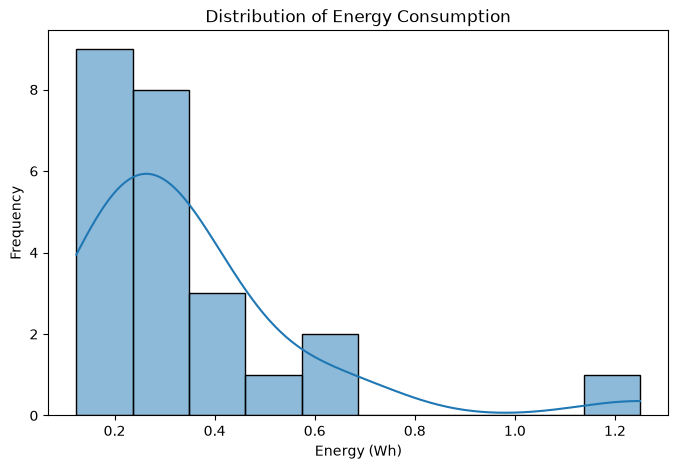

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="energy_wh",
    bins=10,
    kde=True
)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy (Wh)")
plt.ylabel("Frequency")

plt.show()

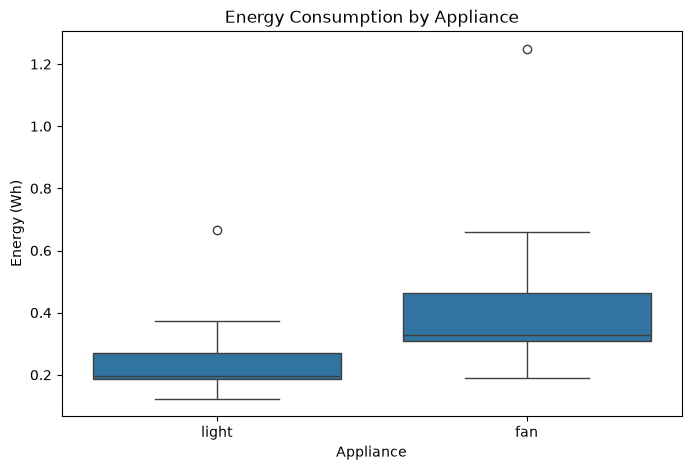

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="appliance",
    y="energy_wh"
)

plt.title("Energy Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Energy (Wh)")

plt.show()

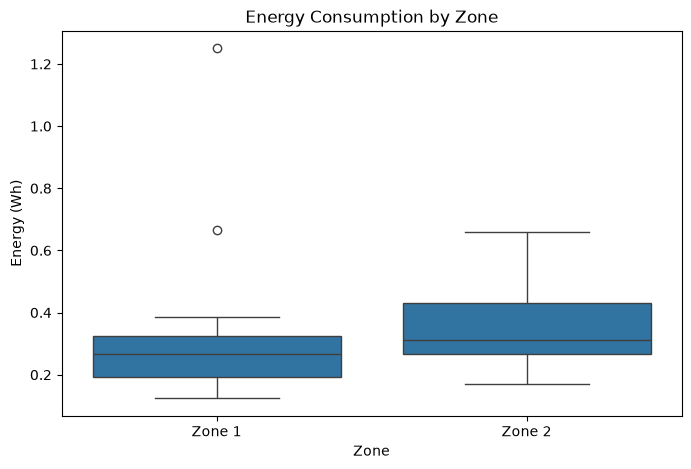

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="zone_name",
    y="energy_wh"
)

plt.title("Energy Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Energy (Wh)")

plt.show()

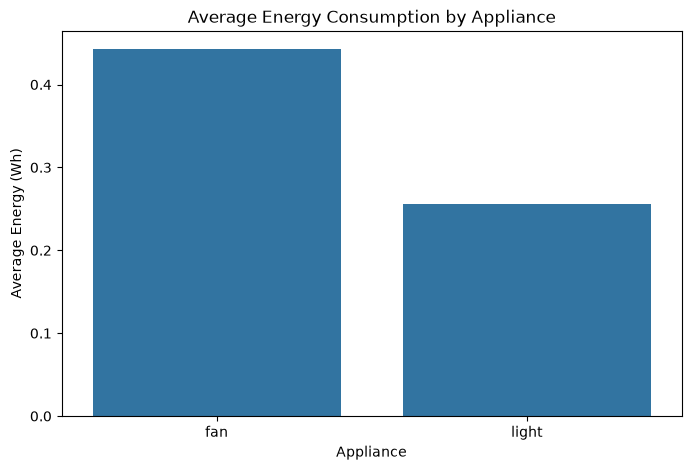

In [31]:
average_appliance_energy = (
    df.groupby("appliance")["energy_wh"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_appliance_energy,
    x="appliance",
    y="energy_wh"
)

plt.title("Average Energy Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Average Energy (Wh)")

plt.show()

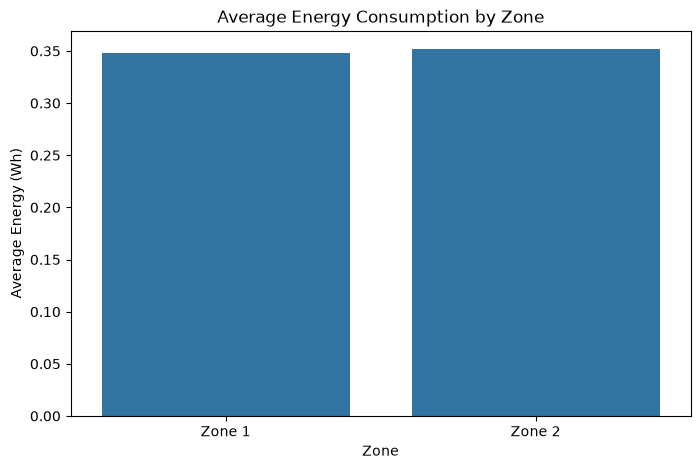

In [32]:
average_zone_energy = (
    df.groupby("zone_name")["energy_wh"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_zone_energy,
    x="zone_name",
    y="energy_wh"
)

plt.title("Average Energy Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Energy (Wh)")

plt.show()

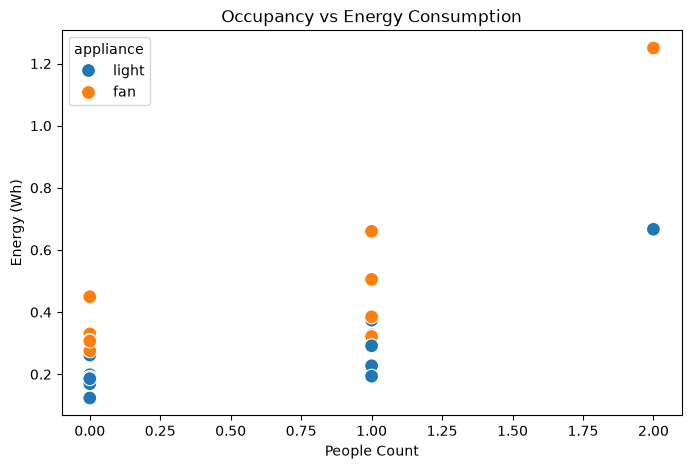

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="people_count",
    y="energy_wh",
    hue="appliance",
    s=100
)

plt.title("Occupancy vs Energy Consumption")
plt.xlabel("People Count")
plt.ylabel("Energy (Wh)")

plt.show()

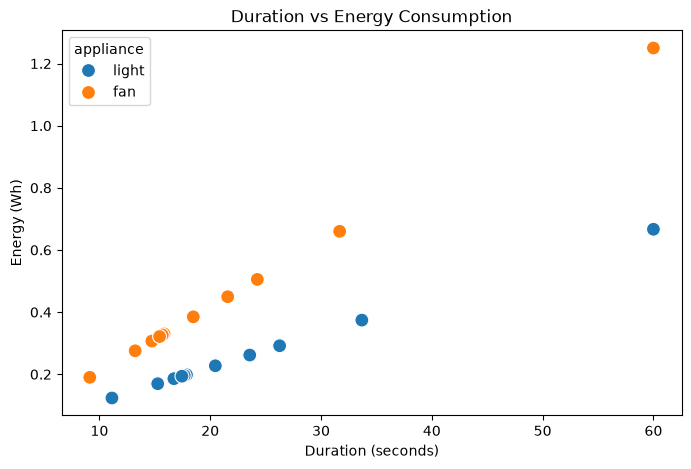

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="duration_seconds",
    y="energy_wh",
    hue="appliance",
    s=100
)

plt.title("Duration vs Energy Consumption")
plt.xlabel("Duration (seconds)")
plt.ylabel("Energy (Wh)")

plt.show()

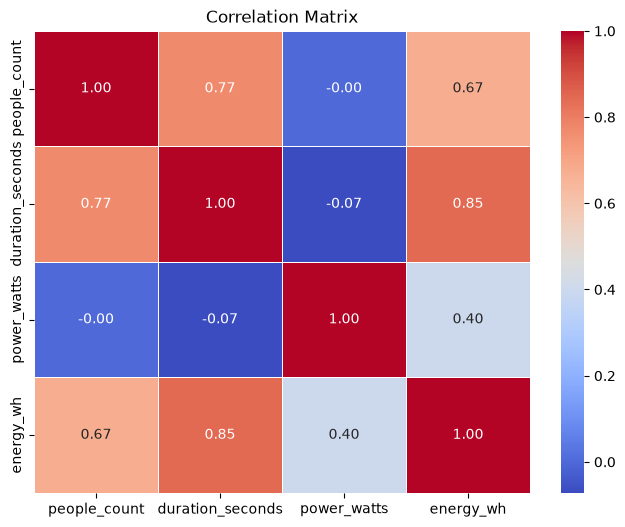

In [35]:
numeric_columns = [
    "people_count",
    "duration_seconds",
    "power_watts",
    "energy_wh"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

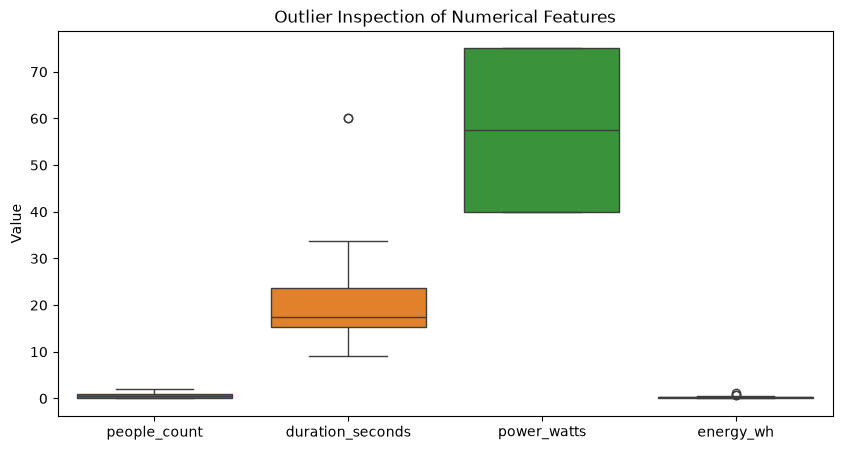

In [36]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[
        [
            "people_count",
            "duration_seconds",
            "power_watts",
            "energy_wh"
        ]
    ]
)

plt.title("Outlier Inspection of Numerical Features")
plt.ylabel("Value")

plt.show()